## Import libraries


In [45]:
import os
from glob import glob

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

import warnings

warnings.filterwarnings("ignore")

WORK_DIR = r"/beegfs/halder/GITHUB/PROJECT/HydroBlocks_DE"
RAW_DATA_DIR = os.path.join(WORK_DIR, "data", "raw")

## Read the region of interest


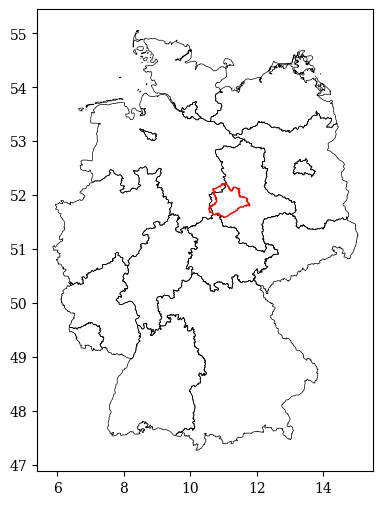

In [49]:
# Read the NUTS1 shapefile for DE
de_nuts1_gdf = gpd.read_file(
    os.path.join("/beegfs", "halder", "DATA", "DE_NUTS", "DE_NUTS_3.shp")
)
de_nuts1_gdf = de_nuts1_gdf[de_nuts1_gdf["LEVL_CODE"] == 1]
de_nuts1_gdf.rename(
    columns={"NUTS_ID": "STATE_ID", "NUTS_NAME": "STATE_NAME"}, inplace=True
)
de_nuts1_gdf.to_crs(crs="EPSG:4326", inplace=True)

# Read the Bode region
roi = gpd.read_file(os.path.join(RAW_DATA_DIR, "ROI", "Bode_catchment.zip"))
roi.to_crs(de_nuts1_gdf.crs, inplace=True)

fig, ax = plt.subplots(figsize=(6, 6))
de_nuts1_gdf.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5, label="NUTS1")
roi.plot(
    ax=ax,
    facecolor="none",
    edgecolor="r",
    linewidth=1,
    label="Bode Hydrological Observatory",
)

plt.show()

## Prepare grid cell


In [ ]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box


def create_grids(roi, resolution=0.25):
    assert roi.crs.to_string() == "EPSG:4326", "ROI must be in EPSG:4326."

    # Get bounding box
    minx, miny, maxx, maxy = roi.total_bounds

    # Create grid coordinates
    lon = np.arange(minx, maxx + resolution, resolution)
    lat = np.arange(miny, maxy + resolution, resolution)

    # Create grid polygons
    polygons = [box(x, y, x + resolution, y + resolution) for x in lon for y in lat]

    grid = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")

    # Keep only grids that intersect ROI
    grid_roi = gpd.sjoin(grid, roi, predicate="intersects", how="inner")

    # Remove join columns
    grid_roi = grid_roi[["geometry"]].reset_index(drop=True)

    return grid_roi

In [ ]:
grid_roi = create_grids(roi)

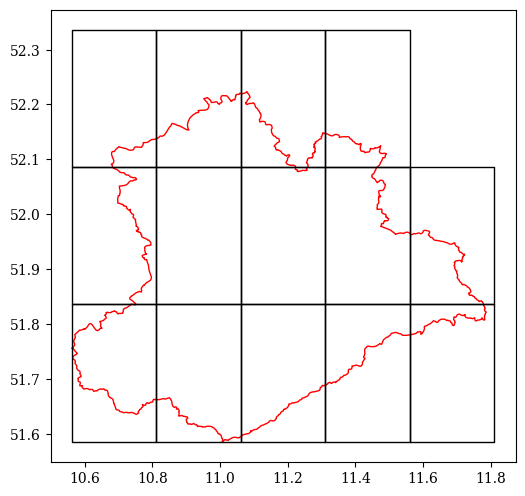

In [81]:
fig, ax = plt.subplots(figsize=(6, 6))

roi.plot(ax=ax, facecolor="none", edgecolor="red")
grid_roi.plot(ax=ax, facecolor="none")

plt.show()

## Prepare the topography and river network data
